# Temas Tratados en el Trabajo Práctico 8

* Aprendizaje estadístico.

* Evolución de la verosimilitud de una hipótesis en función de observaciones.

* Aprendizaje no supervisado. Algoritmo K-means.

* Aprendizaje supervisado. Algoritmo Knn.

* Aprendizaje por refuerzo. Algoritmo Q-Learning.

## Ejercicios Teóricos

1. Un fabricante de tornillos vende cajas que contienen 1000 tornillos de cabeza redonda con tres tipos de recubrimiento electrolítico (cincado, cobre y níquel). Cada caja se rellena
con diferentes proporciones que pueden variar de la siguiente manera:

&emsp;&emsp;a: Todos los tornillos están recubiertos de níquel. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;b: El 70% de los tornillos están recubiertos de níquel, el 20% de cobre, el resto está cincado. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;c: El 50% de los tornillos están recubiertos de níquel, el 25% de cobre y el resto está cincado. 50 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;d: El 20 % de los tornillos están recubiertos de níquel, el 50% de cobre y el resto está cincado. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;e: Todos los tornillos están recubiertos de cobre. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;1.1 ¿Cuál es la distribución a priori sobre las hipótesis?

### Resolución

Cada hipótesis representa un tipo de caja. La **probabilidad a priori** indica qué tan probable es elegir una caja de ese tipo antes de observar los tornillos.

Las proporciones de fabricación y la composición de cada caja son:

| Hipótesis | Níquel | Cobre | Cincado | Probabilidad a priori |
|:---------:|:------:|:-----:|:------:|:---------------------:|
| $h_a$ | 100 % | 0 % | 0 % | 0.15 |
| $h_b$ | 70 % | 20 % | 10 % | 0.15 |
| $h_c$ | 50 % | 25 % | 25 % | 0.50 |
| $h_d$ | 20 % | 50 % | 30 % | 0.10 |
| $h_e$ | 0 % | 100 % | 0 % | 0.10 |

Por lo tanto, la distribución a priori es:

$$
\boxed{P(H)=\langle 0.15,\;0.15,\;0.50,\;0.10,\;0.10\rangle}
$$

Se verifica que:

$$
0.15+0.15+0.50+0.10+0.10=1
$$

Inicialmente, la hipótesis más probable es $h_c$, porque corresponde al 50 % de las cajas fabricadas.

**Supuesto utilizado:** siguiendo la presentación, consideramos las observaciones independientes e idénticamente distribuidas. Esto es exacto si se extrae con reposición y aproximado si no se devuelven los tornillos, ya que se observan solamente 10 de los 1000 tornillos de la caja.

&emsp;Considerando que los 10 primeros tornillos que se extraen de una caja de muestra son de cobre:

&emsp;&emsp;1.2 Calcule la probabilidad de cada hipótesis dado que los 10 primeros tornillos fueron de cobre.

### Resolución

Observamos que los **primeros diez tornillos extraídos son de cobre**. Queremos calcular qué tan probable es cada tipo de caja después de conocer este resultado.

Utilizamos estos símbolos:

- $h_i$: la hipótesis de que la caja pertenece al tipo $i$, donde $i$ puede ser a, b, c, d o e.
- $D_{10}$: el resultado observado, es decir, diez tornillos de cobre consecutivos.
- $P(h_i)$: probabilidad inicial de ese tipo de caja.
- $P(D_{10}\mid h_i)$: probabilidad de obtener diez tornillos de cobre si la caja es de ese tipo. Se llama **verosimilitud**.
- $P(h_i\mid D_{10})$: probabilidad actualizada de ese tipo de caja después de observar los diez tornillos. Se llama **probabilidad posterior**.

El símbolo $\mid$ se lee “dado que” o “sabiendo que”.

### 1. Probabilidad de observar diez tornillos de cobre

Como las extracciones son con reposición, la probabilidad de obtener cobre no cambia entre una extracción y otra.

Por ejemplo, en una caja del tipo b, cada extracción tiene una probabilidad de 0.20 de dar un tornillo de cobre. Para obtener diez seguidos:

$$
P(D_{10}\mid h_b)
=
\underbrace{0.20\times0.20\times\cdots\times0.20}_{10\text{ extracciones}}
=
(0.20)^{10}
$$

Hacemos lo mismo para los demás tipos de caja:

| Tipo de caja | Probabilidad de obtener cobre en una extracción | Probabilidad de obtener diez de cobre seguidos |
|:------------:|:----------------------------------------------:|:----------------------------------------------:|
| a | $0$ | $0^{10}=0$ |
| b | $0.20$ | $(0.20)^{10}=0.0000001024$ |
| c | $0.25$ | $(0.25)^{10}\approx0.000000953674$ |
| d | $0.50$ | $(0.50)^{10}=0.0009765625$ |
| e | $1$ | $1^{10}=1$ |

### 2. Actualización mediante el teorema de Bayes

El teorema de Bayes combina la probabilidad inicial de cada tipo de caja con la probabilidad de obtener los datos observados:

$$
P(h_i\mid D_{10})
=
\frac{P(D_{10}\mid h_i)\,P(h_i)}
{P(D_{10})}
$$

El denominador $P(D_{10})$ es la probabilidad total de obtener diez tornillos de cobre, considerando todos los tipos de caja:

$$
\begin{aligned}
P(D_{10})={}&
0^{10}(0.15)
+(0.20)^{10}(0.15)
+(0.25)^{10}(0.50)\\
&+(0.50)^{10}(0.10)
+1^{10}(0.10)
\end{aligned}
$$

$$
P(D_{10})\approx0.100098148447
$$

Dividir por este valor permite que las probabilidades actualizadas sumen 1.

Por ejemplo, para una caja del tipo e:

$$
P(h_e\mid D_{10})
=
\frac{1^{10}(0.10)}{0.100098148447}
\approx0.99901948
$$

### 3. Resultados

| Tipo de caja | Probabilidad después de observar diez tornillos de cobre |
|:------------:|:-------------------------------------------------------:|
| a | 0 % |
| b | 0.00001534 % |
| c | 0.00047637 % |
| d | 0.09756050 % |
| e | 99.90194779 % |

**Conclusión:** la caja es del tipo e con una probabilidad aproximada de **99.902 %**.

Al principio, el tipo c era el más probable por ser el más fabricado. Sin embargo, obtener diez tornillos de cobre consecutivos favorece fuertemente al tipo e, porque todas sus piezas son de cobre.

El tipo a queda descartado desde la primera extracción de cobre, ya que contiene únicamente tornillos de níquel.


&emsp;&emsp;1.3 Grafique la evolución de la verosimilitud de cada hipótesis en función del número de tornillos extraídos de la caja.

### Resolución

Queremos observar qué ocurre a medida que extraemos tornillos y todos resultan ser de cobre.

Llamamos:

- $n$: cantidad de tornillos extraídos.
- $D_n$: resultado de haber obtenido $n$ tornillos de cobre consecutivos.
- $h_i$: hipótesis de que la caja pertenece al tipo $i$.

El valor $n=0$ representa la situación inicial, antes de extraer tornillos.

Debemos distinguir dos cantidades:

### Verosimilitud: probabilidad de los datos para cada tipo de caja

$$
P(D_n\mid h_i)
=
\left[P(\text{cobre}\mid h_i)\right]^n
$$

Responde a la pregunta:

**“Si la caja fuera de este tipo, ¿qué probabilidad habría de obtener estos resultados?”**

Por ejemplo, para el tipo d:

$$
P(D_n\mid h_d)=(0.50)^n
$$

Antes de observar tornillos, la verosimilitud vale 1 para todas las hipótesis.

### Probabilidad posterior: probabilidad actualizada de cada tipo de caja

$$
P(h_i\mid D_n)
=
\frac{P(D_n\mid h_i)\,P(h_i)}
{\sum_j P(D_n\mid h_j)\,P(h_j)}
$$

El símbolo $\sum_j$ indica que sumamos los términos correspondientes a los cinco tipos de caja.

Esta probabilidad responde a la pregunta:

**“Después de obtener estos resultados, ¿qué tan probable es que la caja sea de este tipo?”**

El primer gráfico muestra la **verosimilitud**, como solicita el enunciado. El segundo muestra la **probabilidad posterior**, para visualizar cómo se actualizan las hipótesis mediante el aprendizaje bayesiano.

Probabilidades después de observar 10 tornillos de cobre:

h_a: 0.000000000000 (0.00000000 %)
h_b: 0.000000153449 (0.00001534 %)
h_c: 0.000004763696 (0.00047637 %)
h_d: 0.000975604959 (0.09756050 %)
h_e: 0.999019477896 (99.90194779 %)

Suma de las probabilidades: 1.000000


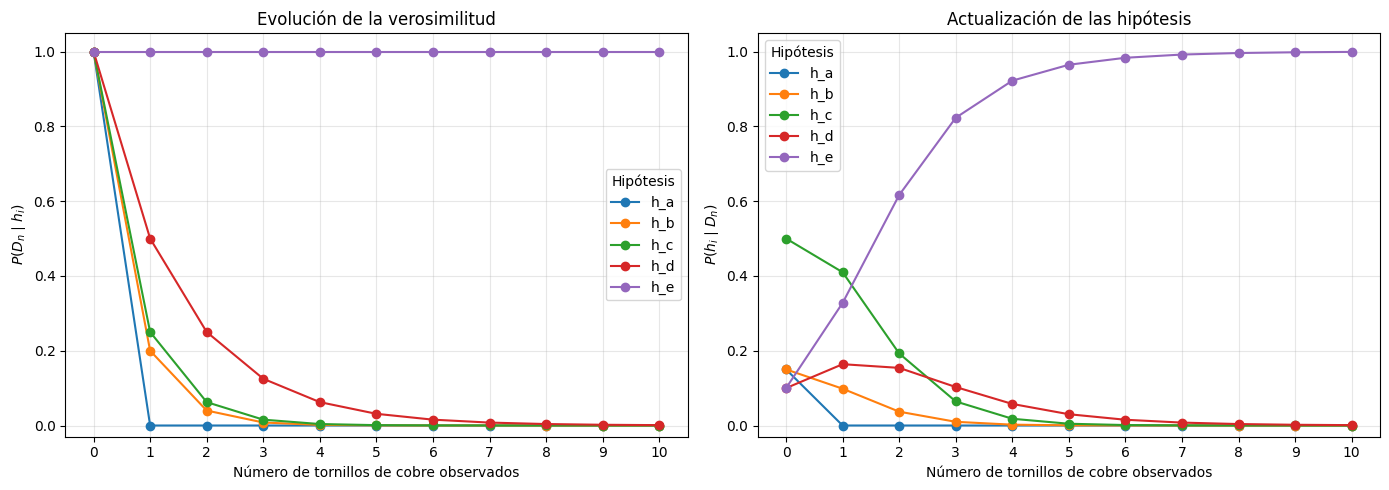

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Hipótesis, probabilidades iniciales y proporción de cobre.
hipotesis = ["h_a", "h_b", "h_c", "h_d", "h_e"]
priori = np.array([0.15, 0.15, 0.50, 0.10, 0.10])
prob_cobre = np.array([0.00, 0.20, 0.25, 0.50, 1.00])

# Incluimos n = 0 para representar la situación sin observaciones.
numero_tornillos = np.arange(11)

# Cada fila corresponde a una cantidad de observaciones.
verosimilitudes = np.ones((11, 5))

# Si todos los tornillos observados son de cobre:
# P(D_n | h_i) = P(cobre | h_i) ** n.
for n in numero_tornillos[1:]:
    verosimilitudes[n] = prob_cobre ** n

# Aplicamos Bayes: multiplicamos por la priori y normalizamos.
pesos = verosimilitudes * priori
evidencias = pesos.sum(axis=1, keepdims=True)
posteriores = pesos / evidencias

# Mostramos los resultados del inciso 1.2.
print("Probabilidades después de observar 10 tornillos de cobre:\n")

for nombre, probabilidad in zip(hipotesis, posteriores[10]):
    print(f"{nombre}: {probabilidad:.12f} ({100 * probabilidad:.8f} %)")

print(f"\nSuma de las probabilidades: {posteriores[10].sum():.6f}")

# Mostramos la verosimilitud y la probabilidad posterior por separado.
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
colores = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

for i, nombre in enumerate(hipotesis):
    ejes[0].plot(
        numero_tornillos,
        verosimilitudes[:, i],
        marker="o",
        color=colores[i],
        label=nombre,
    )

    ejes[1].plot(
        numero_tornillos,
        posteriores[:, i],
        marker="o",
        color=colores[i],
        label=nombre,
    )

ejes[0].set_title("Evolución de la verosimilitud")
ejes[0].set_ylabel(r"$P(D_n \mid h_i)$")

ejes[1].set_title("Actualización de las hipótesis")
ejes[1].set_ylabel(r"$P(h_i \mid D_n)$")

for eje in ejes:
    eje.set_xlabel("Número de tornillos de cobre observados")
    eje.set_xticks(numero_tornillos)
    eje.set_ylim(-0.03, 1.05)
    eje.grid(alpha=0.3)
    eje.legend(title="Hipótesis")

plt.tight_layout()
plt.show()

### Interpretación de los gráficos

En el gráfico de **verosimilitud**:

- $h_a$ pasa a cero desde la primera observación, porque no contiene cobre.
- Para las cajas mixtas, la probabilidad de observar únicamente cobre disminuye al aumentar la cantidad de extracciones.
- $h_e$ mantiene una verosimilitud igual a 1, porque todos sus tornillos son de cobre.

En el gráfico de **probabilidades posteriores**:

- En $n=0$ aparecen las probabilidades a priori.
- $h_e$ aumenta progresivamente hasta acercarse a 1.
- Algunas hipótesis mixtas pueden aumentar inicialmente, pero pierden probabilidad cuando se acumulan más observaciones de cobre.

Esto muestra cómo funciona el **aprendizaje bayesiano**: combinamos las probabilidades iniciales con los datos observados para actualizar la probabilidad de cada hipótesis.

&emsp;&emsp;1.4 Para cada hipótesis, ¿cuál es la probabilidad de que el cuarto tornillo extraído sea de cobre?

### Resolución

Para cada tipo de caja, queremos conocer la probabilidad de que **el cuarto tornillo extraído sea de cobre**.

Llamamos $C_4$ al evento “el cuarto tornillo es de cobre”.

Como trabajamos con reposición, la composición de la caja no cambia. Por eso, para un tipo de caja conocido, la probabilidad de obtener cobre es la misma en la primera, segunda, tercera o cuarta extracción.

| Tipo de caja | Probabilidad de que el cuarto tornillo sea de cobre |
|:------------:|:--------------------------------------------------:|
| a | 0 % |
| b | 20 % |
| c | 25 % |
| d | 50 % |
| e | 100 % |

Por ejemplo:

$$
P(C_4\mid h_b)=0.20
$$

Se lee: “La probabilidad de que el cuarto tornillo sea de cobre, sabiendo que la caja es del tipo b, es del 20 %”.

**Estas probabilidades corresponden a cada tipo de caja conocido.** Las probabilidades del inciso 1.2 responden a otra pregunta: qué tipo de caja tenemos después de observar diez tornillos de cobre.

2. ¿Qué diferencia principal existe entre un algoritmo supervisado y un algoritmo no supervisado?

### Resolución

La principal diferencia entre un **algoritmo supervisado** y un **algoritmo no supervisado** se encuentra en el tipo de datos utilizados durante el aprendizaje.

En el **aprendizaje supervisado**, los datos de entrenamiento se encuentran **etiquetados**. Esto significa que para cada entrada se conoce previamente la salida o clase correcta. El algoritmo utiliza estos ejemplos para aprender una relación entre las entradas y las salidas, de manera que posteriormente pueda predecir la respuesta correspondiente a nuevos datos.

Por ejemplo, el algoritmo **KNN (K-Nearest Neighbors)** puede utilizar puntos cuya clase ya es conocida para determinar a qué clase pertenece un nuevo punto según sus vecinos más cercanos.

En cambio, en el **aprendizaje no supervisado**, los datos no poseen etiquetas ni una respuesta conocida previamente. El algoritmo debe analizar los datos y encontrar por sí mismo patrones, estructuras o agrupaciones.

Por ejemplo, el algoritmo **K-means** divide un conjunto de puntos en grupos o *clusters* según su similitud o cercanía, sin conocer previamente a qué grupo debería pertenecer cada punto.

Por lo tanto, la diferencia principal puede resumirse de la siguiente manera:

- **Aprendizaje supervisado:** aprende a partir de ejemplos con una salida conocida o etiqueta.
- **Aprendizaje no supervisado:** trabaja con datos sin etiquetar e intenta descubrir estructuras o agrupaciones presentes en ellos.

## Ejercicios de implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

3. Genere un conjunto de 23 puntos que contengan coordenadas *xy* aleatorias con valores contenidos en el intervalo [0, 5] y grafique los puntos obtenidos en un gráfico.

&emsp;&emsp;3.1 Implemente un algoritmo K-means que clasifique 20 de los puntos en 2 grupos y grafique el resultado asignando un color a cada uno.


&emsp;&emsp;3.2 Tome los tres puntos restantes y clasifíquelos en los grupos obtenidos anteriormente usando el algoritmo Knn. Utilice distintos valores de K y anote lo que observa con esta elección.

4. La imagen mostrada abajo muestra una red de salas y cómo se comunican entre ellas. Implemente un algoritmo Q-Learning con un factor despreciativo $γ = 0.9$. La matriz de recompensas debe asignar un valor de 0 a cada camino accesible y un valor de 100 a caminos que lleven a la sala del tesoro.

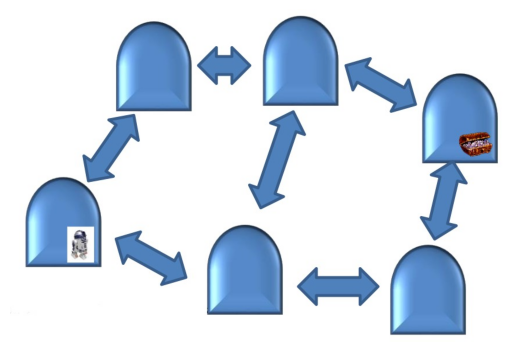

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1dkDruEIPa7f-BAmjI47TZl3bxaqYf6a9"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

&emsp;&emsp;4.1 Dibuje un diagrama con la asignación de recompensas correspondiente a cada estado.

&emsp;&emsp;4.2 Diseñe y muestre la matriz de recompensas.

&emsp;&emsp;4.3 Obtenga la matriz Q óptima, normalícela respecto al valor máximo encontrado y grafique la política obtenida en el diagrama mostrado inicialmente.

## Resolución

### 4.1 Diagrama de recompensas

La imagen contiene **seis salas y siete conexiones bidireccionales**. Como no presenta numeración, se asignan los siguientes estados:

| Estado | Ubicación en la figura |
|---|---|
| 0 | Izquierda, donde aparece el robot |
| 1 | Superior izquierda |
| 2 | Superior central |
| 3 | Superior derecha, con el tesoro |
| 4 | Inferior derecha |
| 5 | Inferior central |

El conjunto de estados es:

$$
S=\{s_0,s_1,s_2,s_3,s_4,s_5\}
$$

El estado objetivo es:

$$
s_{\mathrm{objetivo}}=s_3
$$

Las conexiones identificadas en la imagen son:

$$
0\leftrightarrow1,\quad
0\leftrightarrow5,\quad
1\leftrightarrow2,\quad
2\leftrightarrow3,\quad
2\leftrightarrow5,\quad
3\leftrightarrow4,\quad
4\leftrightarrow5
$$

Todas las conexiones son bidireccionales. No aparecen transiciones de un estado hacia sí mismo, incluido el tesoro.

Las recompensas se asignan según el destino de cada transición:

$$
R_{ij}=
\begin{cases}
100, & \text{si existe la transición } i\to j \text{ y } j=3,\\
0, & \text{si existe la transición } i\to j \text{ y } j\ne3,\\
-1, & \text{si la transición no está permitida}.
\end{cases}
$$

El valor -1 identifica acciones imposibles y no se utiliza como recompensa durante el aprendizaje.

Las transiciones que reciben recompensa 100 son:

$$
2\to3
\qquad\text{y}\qquad
4\to3
$$

Las demás transiciones físicas reciben recompensa 0.

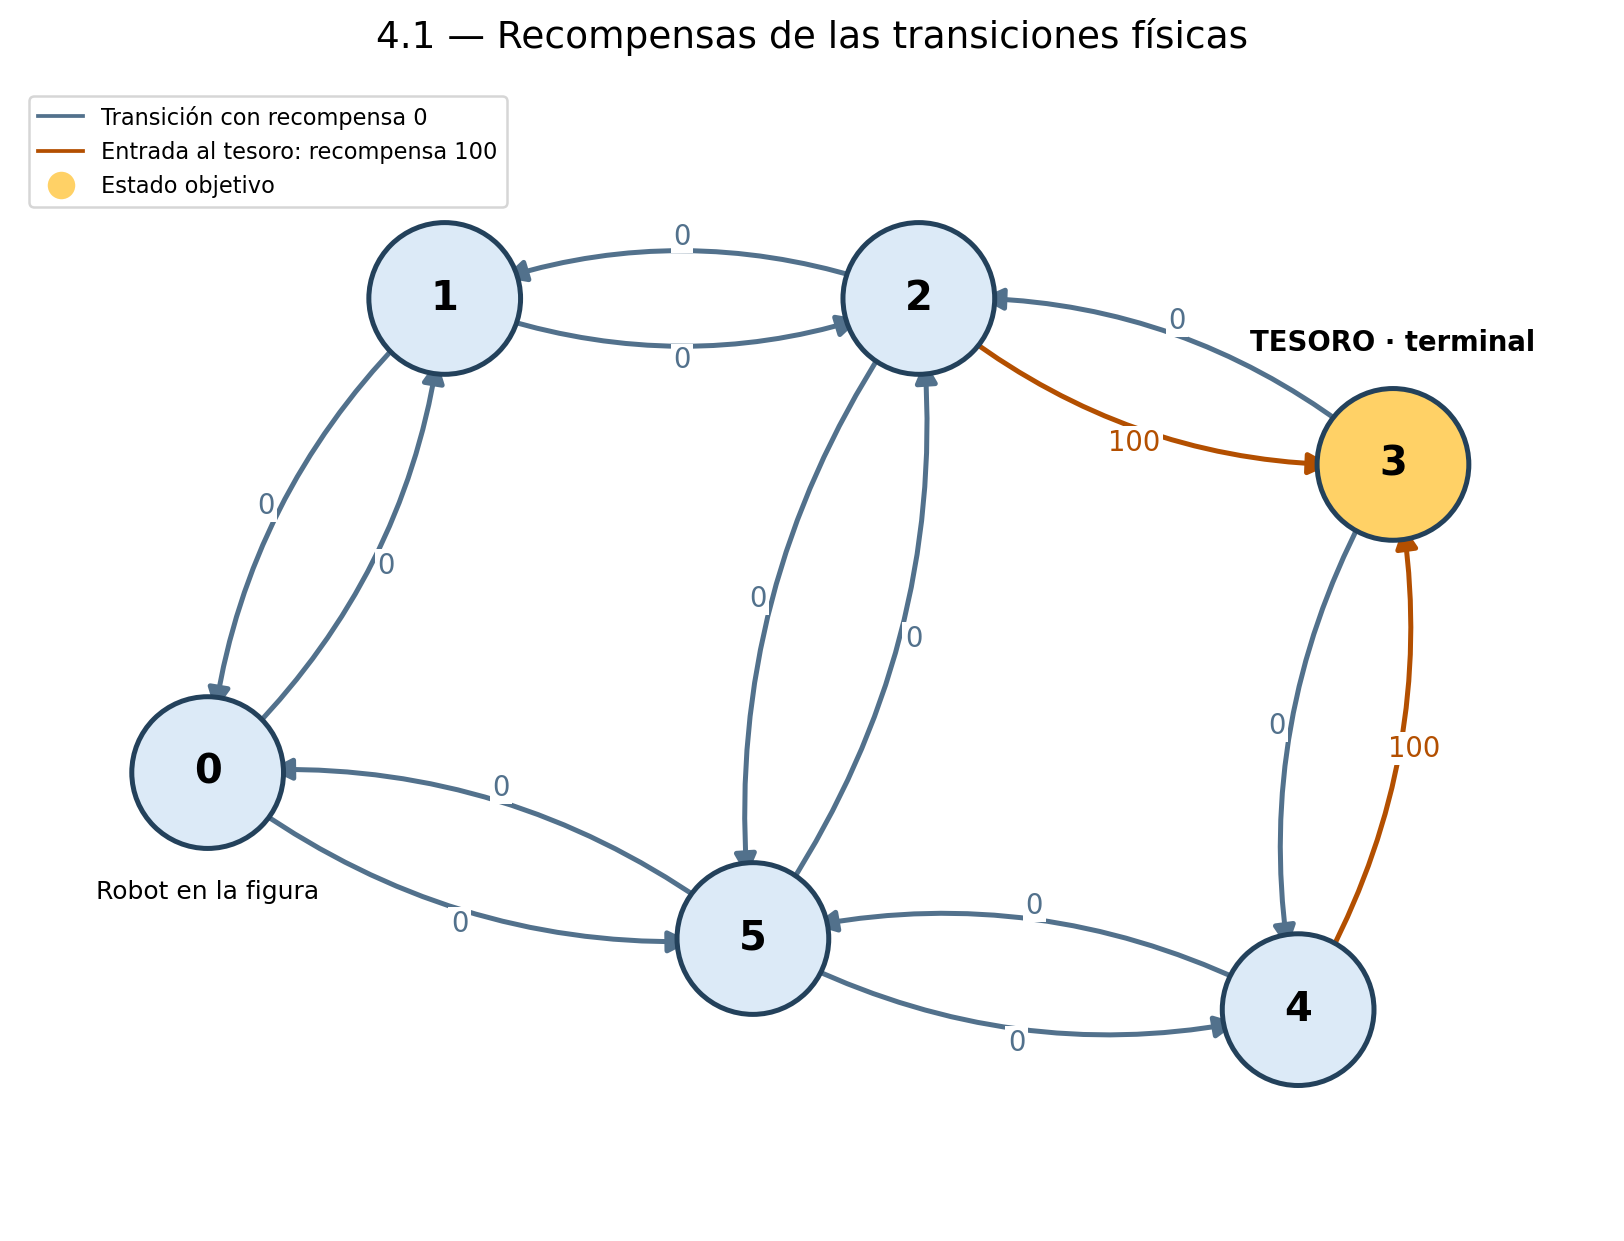
**Condición terminal:** aunque la figura muestra conexiones físicas de salida desde el tesoro, el episodio termina inmediatamente al alcanzarlo. Esas salidas se incluyen en el grafo y en la matriz R, pero no se ejecutan durante el entrenamiento.

### 4.2 Matriz de recompensas

Las conexiones y recompensas identificadas son:

| Estado de origen | Destinos y recompensas |
|---|---|
| 0 | Hacia 1: 0; hacia 5: 0 |
| 1 | Hacia 0: 0; hacia 2: 0 |
| 2 | Hacia 1: 0; hacia 3: 100; hacia 5: 0 |
| 3 | Hacia 2: 0; hacia 4: 0. Salidas físicas del estado terminal |
| 4 | Hacia 3: 100; hacia 5: 0 |
| 5 | Hacia 0: 0; hacia 2: 0; hacia 4: 0 |

Ordenando las filas y columnas como 0, 1, 2, 3, 4 y 5, se obtiene:

$$
R=
\begin{bmatrix}
-1&0&-1&-1&-1&0\\
0&-1&0&-1&-1&-1\\
-1&0&-1&100&-1&0\\
-1&-1&0&-1&0&-1\\
-1&-1&-1&100&-1&0\\
0&-1&0&-1&0&-1
\end{bmatrix}
$$

Cada fila representa la sala de origen y cada columna representa la sala de destino.

La diagonal contiene -1 porque la figura no incluye bucles. Una entrada 0 representa una transición válida sin recompensa inmediata; una entrada -1 representa una transición prohibida.

### 4.3 Q-Learning

Se utiliza el factor de descuento:

$$
\gamma=0.9
$$

La ecuación de actualización es:

$$
Q(s,a)\leftarrow R(s,a)+\gamma\max_{a'\in A(s')}Q(s',a')
$$

Los términos representan:

- **s:** estado actual.
- **a:** acción seleccionada, identificada mediante la sala de destino.
- **s':** estado alcanzado.
- **R(s,a):** recompensa inmediata.
- **A(s'):** conjunto de acciones válidas del siguiente estado.
- **Gamma:** factor de descuento.
- **Máximo de Q en el siguiente estado:** mejor valor futuro estimado.

La actualización utilizada corresponde a una tasa de aprendizaje igual a 1:

$$
\alpha=1
$$

Como el tesoro termina el episodio, el valor futuro al alcanzarlo es cero:

$$
Q(s,a)\leftarrow
\begin{cases}
R(s,a), & s'=3,\\
R(s,a)+0.9\max_{a'\in A(s')}Q(s',a'), & s'\ne3.
\end{cases}
$$

Se inicializó la matriz Q en cero y se realizaron episodios con estados iniciales no terminales aleatorios y selección uniforme de acciones válidas. Se utilizó la semilla 42.

El entrenamiento finalizó después de **5.000 episodios**, tras verificar cobertura de todas las acciones no terminales y estabilidad de la ecuación de Bellman en cinco controles consecutivos.

La matriz obtenida mediante el algoritmo fue:

$$
Q=
\begin{bmatrix}
0&81&0&0&0&81\\
72.9&0&90&0&0&0\\
0&81&0&100&0&81\\
0&0&0&0&0&0\\
0&0&0&100&0&81\\
72.9&0&90&0&90&0
\end{bmatrix}
$$

Los ceros correspondientes a conexiones imposibles son relleno y se excluyen de las maximizaciones.

La fila del estado 3 se mantiene en cero porque el episodio finaliza al llegar al tesoro. No representa valores aprendidos para continuar saliendo de ese estado.

#### Normalización

El máximo encontrado fue:

$$
Q_{\max}=\max_{i,j}Q_{ij}=100
$$

Se normaliza mediante:

$$
Q_{\mathrm{norm}}=\frac{Q}{Q_{\max}}\times100
$$

La matriz normalizada es:

$$
Q_{\mathrm{norm}}=
\begin{bmatrix}
0&81&0&0&0&81\\
72.9&0&90&0&0&0\\
0&81&0&100&0&81\\
0&0&0&0&0&0\\
0&0&0&100&0&81\\
72.9&0&90&0&90&0
\end{bmatrix}
$$

La normalización conserva los valores porque el máximo de Q ya es 100.

#### Política óptima

La política se obtiene considerando únicamente acciones válidas:

$$
\pi(s)=\operatorname*{arg\,max}_{a\in A(s)}Q(s,a)
$$

Se conservan todas las alternativas cuando existe un empate.

| Estado | Siguiente estado óptimo | Valor de la acción |
|---|---|---|
| 0 | 1 o 5, empate | 81 |
| 1 | 2 | 90 |
| 2 | 3 | 100 |
| 3 | Finalizar el episodio | — |
| 4 | 3 | 100 |
| 5 | 2 o 4, empate | 90 |

Desde la sala del robot existen tres recorridos óptimos:

$$
0\to1\to2\to3
$$

$$
0\to5\to2\to3
$$

$$
0\to5\to4\to3
$$
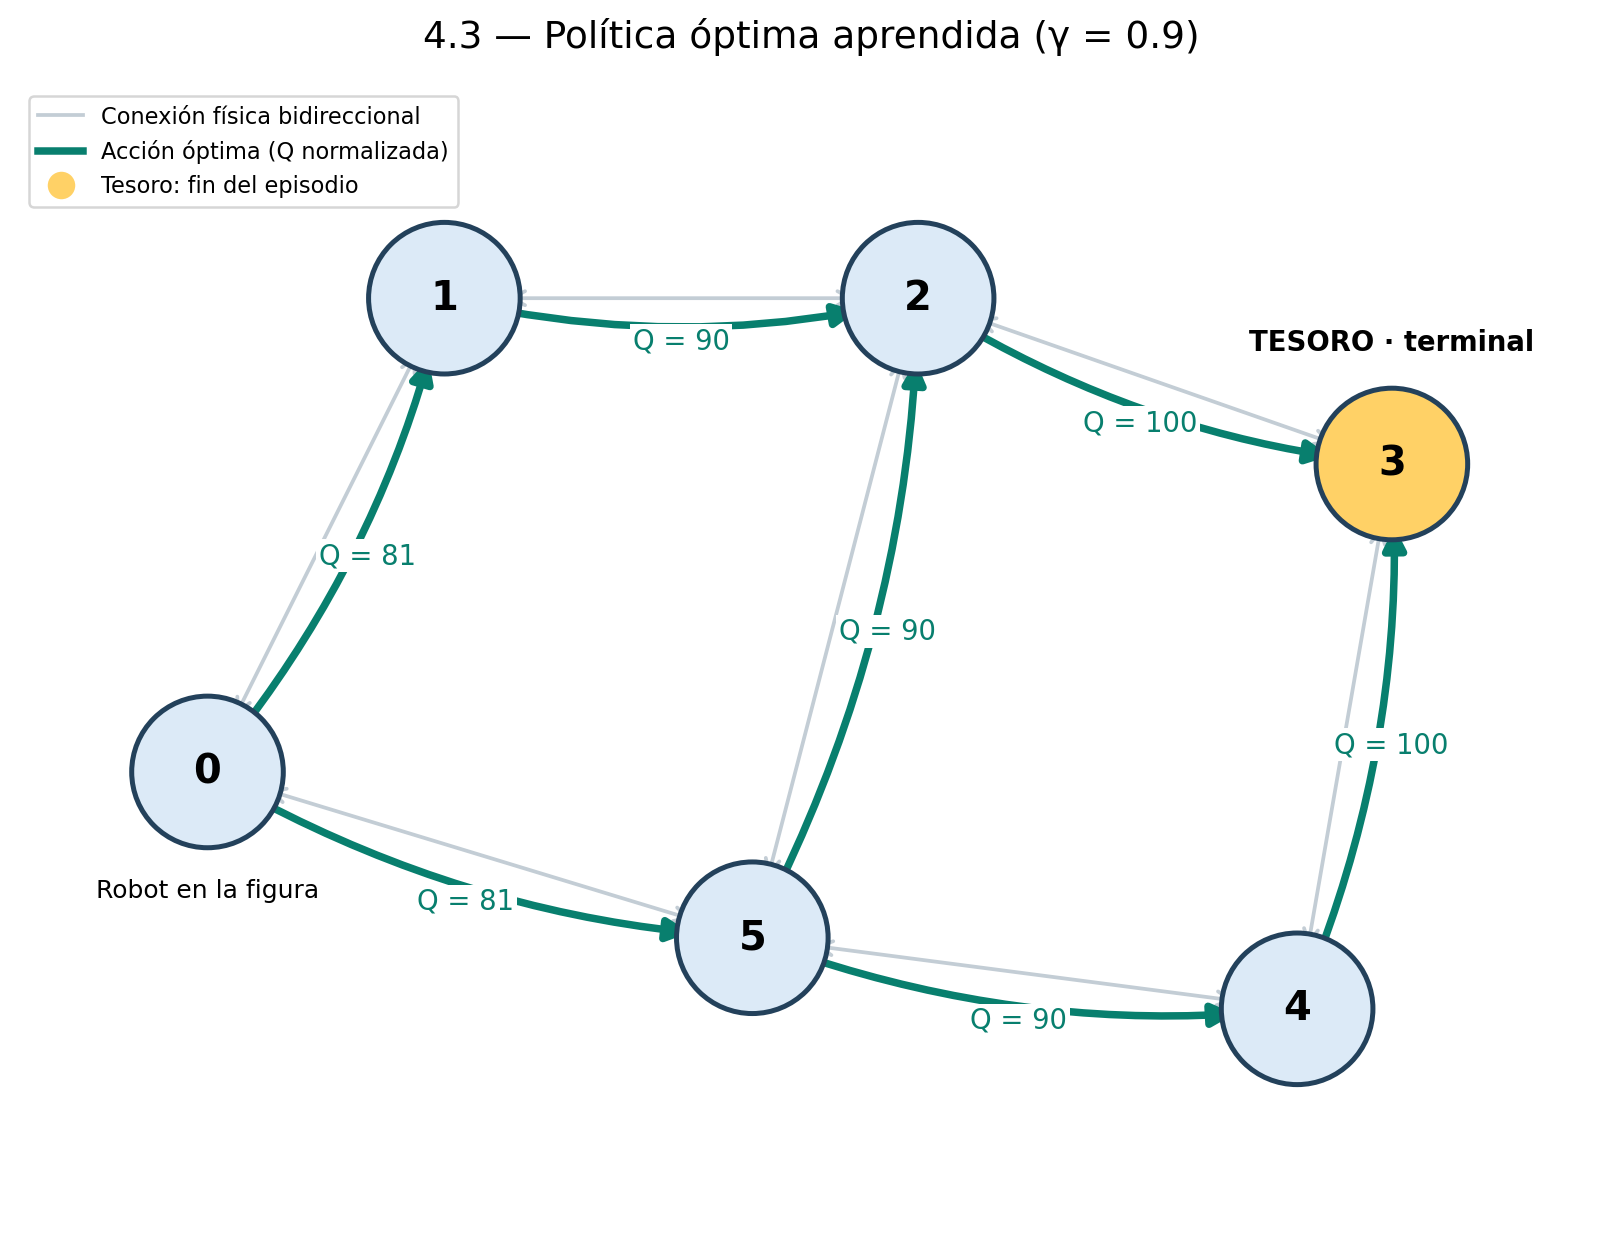
En el gráfico de la política, las conexiones grises representan la red física original y las flechas verdes destacan todas las acciones óptimas, incluidos los empates.



Matriz R:
 [[ -1   0  -1  -1  -1   0]
 [  0  -1   0  -1  -1  -1]
 [ -1   0  -1 100  -1   0]
 [ -1  -1   0  -1   0  -1]
 [ -1  -1  -1 100  -1   0]
 [  0  -1   0  -1   0  -1]]

Matriz Q:
 [[  0.   81.    0.    0.    0.   81. ]
 [ 72.9   0.   90.    0.    0.    0. ]
 [  0.   81.    0.  100.    0.   81. ]
 [  0.    0.    0.    0.    0.    0. ]
 [  0.    0.    0.  100.    0.   81. ]
 [ 72.9   0.   90.    0.   90.    0. ]]

Valor máximo de Q:
 100.0

Matriz Q normalizada:
 [[  0.   81.    0.    0.    0.   81. ]
 [ 72.9   0.   90.    0.    0.    0. ]
 [  0.   81.    0.  100.    0.   81. ]
 [  0.    0.    0.    0.    0.    0. ]
 [  0.    0.    0.  100.    0.   81. ]
 [ 72.9   0.   90.    0.   90.    0. ]]

Política óptima:
Estado 0 -> Estado 1 o Estado 5 (empate)
Estado 1 -> Estado 2
Estado 2 -> Estado 3
Estado 3: tesoro; finalizar episodio.
Estado 4 -> Estado 3
Estado 5 -> Estado 2 o Estado 4 (empate)

Episodios: 5000; residuo de Bellman: 0.00e+00
Verificaciones: todas correctas.


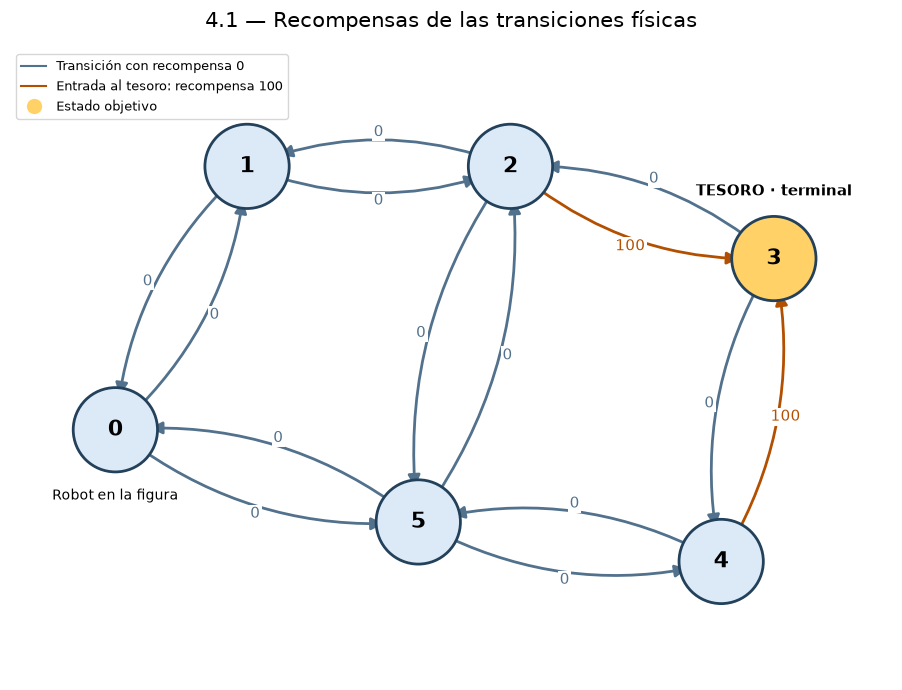

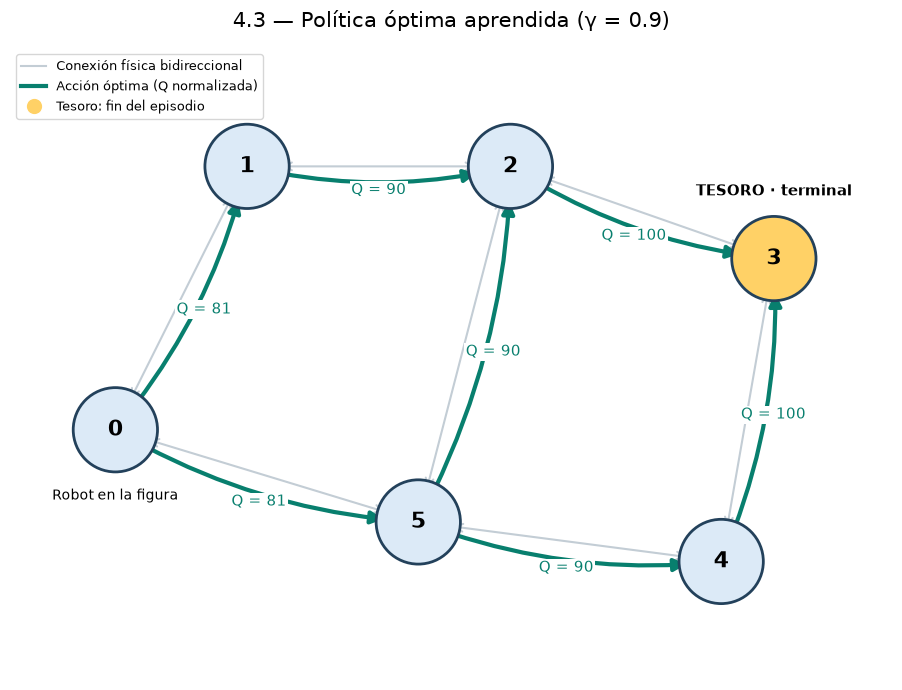

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
from matplotlib.lines import Line2D

# 1. Definición de estados y conexiones
# La imagen no tiene números: se asignan según la posición de las salas.
n = 6
estados = np.arange(n)
tesoro = 3
gamma = 0.9
rng = np.random.default_rng(42)

# 0: robot; 1: superior izquierda; 2: superior central;
# 3: tesoro; 4: inferior derecha; 5: inferior central.
pos = np.array([
    (0, 1), (1, 3), (3, 3),
    (5, 2.3), (4.6, 0), (2.3, 0.3)
], dtype=float)

conexiones = [
    (0, 1), (1, 2), (2, 3), (2, 5),
    (3, 4), (4, 5), (5, 0)
]

# 2. Construcción de la matriz R
R = np.full((n, n), -1, dtype=int)

for i, j in conexiones:
    R[i, j] = 100 if j == tesoro else 0
    R[j, i] = 100 if i == tesoro else 0

valida = R >= 0
acciones = [np.flatnonzero(valida[s]) for s in estados]
no_terminales = estados[estados != tesoro]

# R describe conexiones físicas. El episodio termina al entrar al tesoro.
# -1 es una marca de acción prohibida: nunca se usa como recompensa.

# 3. Visualización de recompensas
def base(titulo):
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set(
        xlim=(-0.8, 5.9), ylim=(-0.9, 3.9),
        aspect="equal"
    )
    ax.axis("off")
    ax.set_title(titulo, fontsize=15, pad=15)

    for s, (x, y) in enumerate(pos):
        color = "#FFD166" if s == tesoro else "#DCEAF7"
        ax.add_patch(Circle(
            (x, y), 0.32, facecolor=color,
            edgecolor="#23415B", linewidth=2, zorder=4
        ))
        ax.text(
            x, y, str(s), ha="center", va="center",
            fontsize=16, weight="bold", zorder=5
        )

    ax.text(
        *(pos[tesoro] + [0, 0.48]), "TESORO · terminal",
        ha="center", fontsize=11, weight="bold"
    )
    ax.text(
        *(pos[0] + [0, -0.53]), "Robot en la figura",
        ha="center", fontsize=10
    )
    return fig, ax


def flecha(ax, i, j, color, curva=0, grosor=2, etiqueta=None):
    p, q = pos[i], pos[j]

    ax.add_patch(FancyArrowPatch(
        p, q, arrowstyle="-|>", mutation_scale=18,
        connectionstyle=f"arc3,rad={curva}",
        shrinkA=25, shrinkB=25,
        color=color, linewidth=grosor, zorder=2
    ))

    if etiqueta is not None:
        d = q - p
        normal = np.array([d[1], -d[0]]) / np.linalg.norm(d)
        centro = (
            (p + q) / 2
            + normal * (curva * np.linalg.norm(d) / 2 + 0.06)
        )
        ax.text(
            *centro, str(etiqueta), color=color, fontsize=11,
            ha="center", va="center", zorder=6,
            bbox=dict(facecolor="white", edgecolor="none", pad=1)
        )


fig_R, ax = base("4.1 — Recompensas de las transiciones físicas")

for i, j in conexiones:
    for s, a in [(i, j), (j, i)]:
        color = "#B34F00" if R[s, a] == 100 else "#52718C"
        flecha(ax, s, a, color, curva=0.20, etiqueta=R[s, a])

ax.legend(handles=[
    Line2D(
        [0], [0], color="#52718C",
        label="Transición con recompensa 0"
    ),
    Line2D(
        [0], [0], color="#B34F00",
        label="Entrada al tesoro: recompensa 100"
    ),
    Line2D(
        [0], [0], marker="o", color="w",
        markerfacecolor="#FFD166", markersize=12,
        label="Estado objetivo"
    )
], loc="upper left", fontsize=9)

fig_R.tight_layout()

# 4. Inicialización de Q
Q = np.zeros((n, n), dtype=float)
visitas = np.zeros((n, n), dtype=int)

# Los ceros de acciones imposibles son relleno, no valores de acciones.
# La fila terminal queda en cero: allí no se toman decisiones.

# 5. Entrenamiento Q-Learning
# Actualización con alpha=1 para este entorno determinista.
def futuro(s):
    if s == tesoro:
        return 0.0
    return np.max(Q[s, acciones[s]])


def residuo_bellman():
    return max(
        abs(Q[s, a] - (R[s, a] + gamma * futuro(a)))
        for s in no_terminales
        for a in acciones[s]
    )


max_episodios = 20000
bloques_estables = 0

for episodio in range(1, max_episodios + 1):
    s = int(rng.choice(no_terminales))

    while s != tesoro:
        # 1 y 2: obtener acciones válidas y seleccionar una.
        a = int(rng.choice(acciones[s]))

        # 3: la acción identifica directamente el siguiente estado.
        siguiente = a

        # 4: actualizar Q; futuro(tesoro) vale cero.
        Q[s, a] = R[s, a] + gamma * futuro(siguiente)
        visitas[s, a] += 1

        # 5 y 6: avanzar y terminar si se llegó al tesoro.
        s = siguiente

    # Exigir convergencia en cinco controles separados por 1000 episodios.
    if episodio % 1000 == 0:
        cobertura = all(
            visitas[s, a] > 0
            for s in no_terminales
            for a in acciones[s]
        )
        estable = cobertura and residuo_bellman() < 1e-10
        bloques_estables = bloques_estables + 1 if estable else 0

        if bloques_estables >= 5:
            break

assert bloques_estables >= 5, "No se alcanzó la convergencia requerida."

# 6. Normalización de Q
Q_max = Q.max()
assert Q_max > 0

Q_norm = Q / Q_max * 100

# 7. Obtención de la política óptima
# Se conservan TODOS los destinos que comparten el máximo.
politica = {}

for s in no_terminales:
    disponibles = acciones[s]
    mejor = np.max(Q[s, disponibles])

    politica[s] = disponibles[
        np.isclose(
            Q[s, disponibles], mejor,
            rtol=0, atol=1e-9
        )
    ].tolist()

np.set_printoptions(precision=2, suppress=True)

print("Matriz R:\n", R)
print("\nMatriz Q:\n", np.round(Q, 2))
print("\nValor máximo de Q:\n", Q_max)
print("\nMatriz Q normalizada:\n", np.round(Q_norm, 2))
print("\nPolítica óptima:")

for s in estados:
    if s == tesoro:
        print(f"Estado {s}: tesoro; finalizar episodio.")
    else:
        destinos = " o ".join(f"Estado {a}" for a in politica[s])
        empate = " (empate)" if len(politica[s]) > 1 else ""
        print(f"Estado {s} -> {destinos}{empate}")

print(
    f"\nEpisodios: {episodio}; "
    f"residuo de Bellman: {residuo_bellman():.2e}"
)

# 8. Visualización de la política
fig_pi, ax = base("4.3 — Política óptima aprendida (γ = 0.9)")

# Red física original, en segundo plano.
for i, j in conexiones:
    ax.add_patch(FancyArrowPatch(
        pos[i], pos[j], arrowstyle="<->", mutation_scale=14,
        shrinkA=25, shrinkB=25,
        color="#C3CDD5", linewidth=1.5, zorder=1
    ))

# Política calculada a partir de Q, incluidos los empates.
for s, destinos in politica.items():
    for a in destinos:
        flecha(
            ax, s, a, "#087F6E", curva=0.12, grosor=3,
            etiqueta=f"Q = {Q_norm[s, a]:.0f}"
        )

ax.legend(handles=[
    Line2D(
        [0], [0], color="#C3CDD5",
        label="Conexión física bidireccional"
    ),
    Line2D(
        [0], [0], color="#087F6E", lw=3,
        label="Acción óptima (Q normalizada)"
    ),
    Line2D(
        [0], [0], marker="o", color="w",
        markerfacecolor="#FFD166", markersize=12,
        label="Tesoro: fin del episodio"
    )
], loc="upper left", fontsize=9)

fig_pi.tight_layout()

# 9. Verificación de resultados
def alcanza_tesoro(inicio, vecinos):
    pendientes, vistos = [int(inicio)], set()

    while pendientes:
        s = pendientes.pop()

        if s == tesoro:
            return True

        if s not in vistos:
            vistos.add(s)
            pendientes.extend(vecinos[s])

    return False


# 1. Ninguna acción óptima utiliza conexiones inexistentes.
# 3. Todas las acciones elegidas son máximos entre las válidas.
for s, destinos in politica.items():
    assert destinos and all(valida[s, a] for a in destinos)
    assert all(
        np.isclose(Q[s, a], np.max(Q[s, acciones[s]]))
        for a in destinos
    )

# 2. Existe un camino al tesoro en la red y en la política.
vecinos_pi = {s: politica.get(s, []) for s in estados}
assert all(alcanza_tesoro(s, acciones) for s in estados)
assert all(alcanza_tesoro(s, vecinos_pi) for s in estados)

# Verificación adicional: ninguna alternativa óptima genera ciclos.
# Cada acción óptima no terminal aumenta estrictamente V.
V = np.array([futuro(s) for s in estados])
assert all(
    a == tesoro or V[a] > V[s]
    for s, destinos in politica.items()
    for a in destinos
)

# 4. El máximo normalizado es 100.
assert np.isclose(Q_norm.max(), 100.0)

# 5. El factor utilizado es 0.9.
assert gamma == 0.9

# Comprobaciones adicionales.
assert residuo_bellman() < 1e-10
assert np.all(Q[~valida] == 0)
assert np.all(Q[tesoro] == 0)
assert not np.any(np.diag(valida))

print("Verificaciones: todas correctas.")

fig_R.savefig("ej4_recompensas.png", dpi=180, bbox_inches="tight")
fig_pi.savefig("ej4_politica.png", dpi=180, bbox_inches="tight")
plt.show()

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2017) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)